# F1 Pit Stop Strategy Analysis Using Clustering Techniques



In [3]:
pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=1ece5f87eb4ec0b095fc1ab2fe7c7d9ad2329b7f4562d7d4bf207a09ad2f0e4e
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [24]:
# import libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage
from sklearn.metrics import silhouette_score


# Part 1

### Research Question

How can clustering techniques be used to identify patterns in F1 pit stop strategies based on average pit stop duration and average laps before before stops?

Pit stop strategies play a major role in Formula 1 race performance. Teams must balance speed, tire management and race timing to gain competitive advantages during races. Analyzing pit stop data can help reveal hidden strategy patterns among drivers or teams. By using clustering techniques, observations with similar pit stop behaviors can be grouped together without predefined labels. This makes the analysis useful for understanding different racing strategies such as aggressive early stop approaches, balanced strategies or longer tire management strategies. Clustering teechniques such as k-means and hierarchical
clustering are appropriate because they can identify natural groupings and hidden strategy patterns within the numerical race data.

In [25]:
# Load data
df = pd.read_csv(
    'https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS'
    '/refs/heads/main/data/f1_driver_classification_data.csv'
)
df.head(3)

,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop,top3_finish
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1.0,1.0,85.296,58,2.0,23.3195,45.0,24.280365,37.856,16.867,23.055556,1
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2.0,2.0,85.384,58,2.0,23.2130,45.0,24.280365,37.856,16.867,23.055556,1
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6.0,6.0,85.543,58,2.0,25.1090,45.0,24.280365,37.856,16.867,23.055556,1


In [26]:
df.columns

Index(['race_year', 'race_circuit', 'race_country', 'race_altitude_m', 'team',
       'race_start_position', 'qualifying_position', 'quali_lap_time_s',
       'laps_completed', 'driver_pit_stops_count',
       'driver_pit_stops_avg_duration_s', 'race_pit_stops_count',
       'race_pit_stops_avg_duration_s', 'race_pit_stops_max_duration_s',
       'race_pit_stops_min_duration_s', 'race_avg_laps_before_pit_stop',
       'top3_finish'],
      dtype='object')

In [27]:
# select only 2 columns
features = df[['driver_pit_stops_avg_duration_s', 'race_avg_laps_before_pit_stop']]

### Variables used

**driver_pit_stops_avg_duration_s** - Average duration of pit stops in seconds for a driver during a  race.

**race_avg_laps_before_pit_stop** - Average number of laps completed before making a pit stop.

In [28]:
# Normalize the variables
scaler = StandardScaler()
features = scaler.fit_transform(features)

# Part 2

### K-Means Clustering

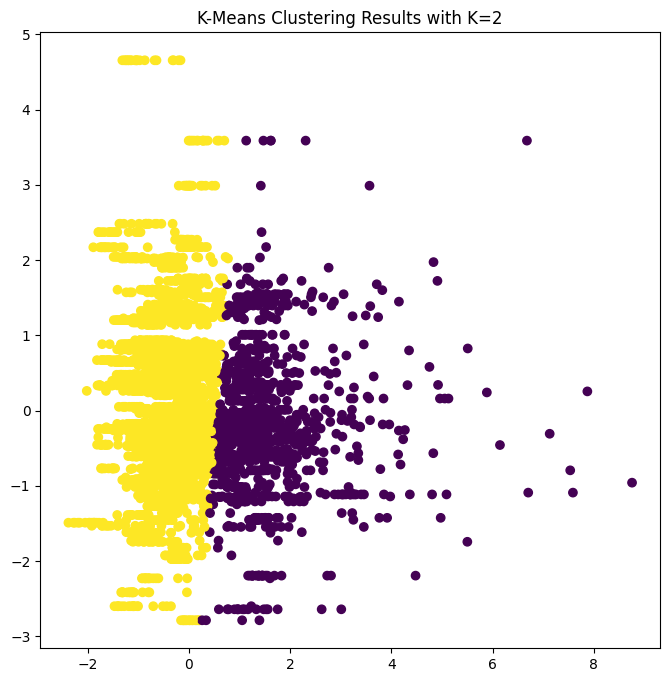

In [29]:
# apply k-means with 2 clusters
kmeans_2 = KMeans(n_clusters = 2,
                  random_state = 2,
                  n_init = 20).fit(features)
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(features[:,0], features[:,1], c=kmeans_2.labels_)
ax.set_title("K-Means Clustering Results with K=2");

For K=2, the observations are divided into 2 braod groups, mainly seperating races based on pit stop strategy differences. While this provided a simple overview, the clusters were quite general and did not capture more detailed strategy variations.

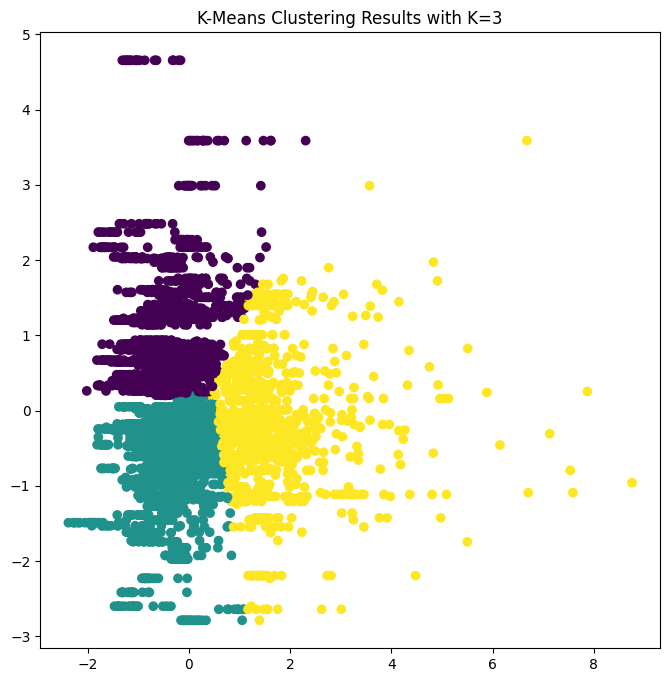

In [30]:
# apply K=3
kmeans_3 = KMeans(n_clusters = 3,
                  random_state = 2,
                  n_init = 20).fit(features)
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(features[:,0], features[:,1], c=kmeans_3.labels_)
ax.set_title("K-Means Clustering Results with K=3");

For K=3, the clustering produced more meaningful seperation among the observations. The groups appeared to distinguish different combinations of pit stop timing and pit stop duration suggesting aggresive, balanced and conservative race strategies. The clusters are more interpretable and showed clearer structure compared to K=2.

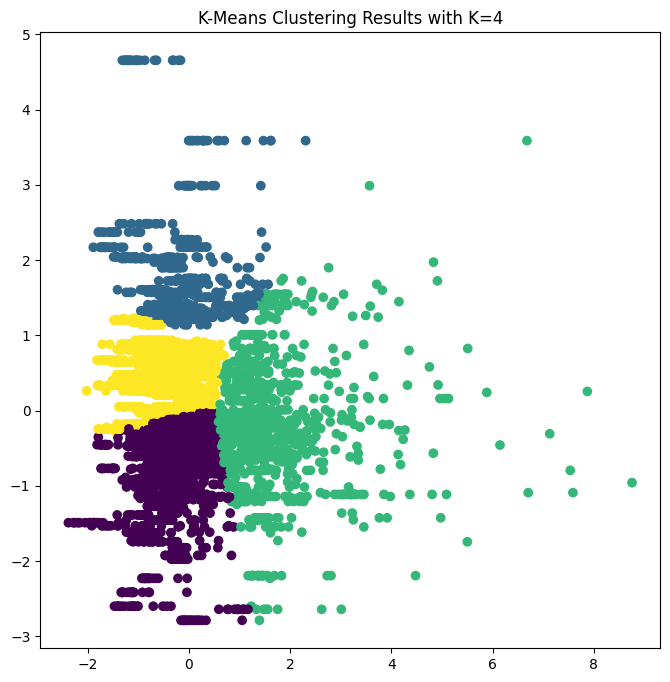

In [31]:
# Apply K=4
kmeans_4 = KMeans(n_clusters = 4,
                  random_state = 20,
                  n_init = 20).fit(features)
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(features[:,0], features[:,1], c=kmeans_4.labels_)
ax.set_title("K-Means Clustering Results with K=4");

For K=4, the observations were seperated into smaller and more detailed groups. Although this provides additional granularity, some clusters appeared more fragmented and overlapping, which may indicate over segmentationn of data.

Overall, K=3 appears to provide the best balance between simplicity and cluster seperation. It captures important variations in pit stop behavior while maintaining interpretable and reasonably distinct clusters within the dataset.

In [32]:
# Compare several possible values of K
K_elbow = range(1, 11)
K_silhouette = range(2, 11)

inertias = []
silhouette_scores = []

# Inertia can be computed for K = 1, 2, ..., 10
for k in K_elbow:
    kmeans = KMeans(n_clusters=k,
                    random_state=2,
                    n_init=20).fit(features)
    inertias.append(kmeans.inertia_)

# Silhouette score is only defined when there are at least two clusters
for k in K_silhouette:
    kmeans = KMeans(n_clusters=k,
                    random_state=2,
                    n_init=20).fit(features)
    silhouette_scores.append(silhouette_score(features, kmeans.labels_))

k_summary = pd.DataFrame({
    'K': list(K_elbow),
    'Inertia': inertias,
    'Silhouette Score': [np.nan] + silhouette_scores
})

k_summary

,K,Inertia,Silhouette Score
0,1,11940.000000,NaN
1,2,7992.054075,0.421365
2,3,4872.108472,0.429706
3,4,4148.069046,0.360576
4,5,3512.627814,0.368856
5,6,2948.438102,0.365785
6,7,2531.067008,0.368755
7,8,2255.458503,0.352765
8,9,2017.067229,0.361287
9,10,1822.794545,0.367239


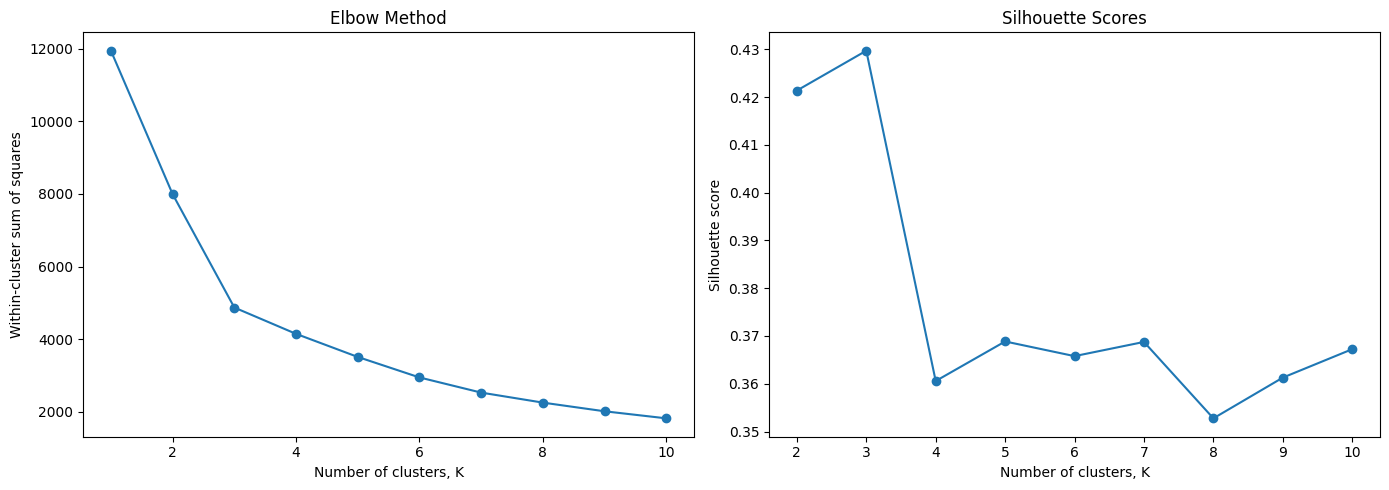

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax[0].plot(list(K_elbow), inertias, marker='o')
ax[0].set_xlabel("Number of clusters, K")
ax[0].set_ylabel("Within-cluster sum of squares")
ax[0].set_title("Elbow Method")

# Silhouette plot
ax[1].plot(list(K_silhouette), silhouette_scores, marker='o')
ax[1].set_xlabel("Number of clusters, K")
ax[1].set_ylabel("Silhouette score")
ax[1].set_title("Silhouette Scores")

plt.tight_layout();

The elbow method and silhouette scores were used to evaluate the appropriate number of clusters for F1 pit stop dataset. The elbow plot shows a sharp decrease in within-cluster sum of squares from K=1 to K=3, after which the reduction becomes more gradual. This indicates that K=3 is a reasonable choice because adding more clusters beyond this point provides only limited improvement in cluster compactness.

The Silhouette scores also support this conclusion. The highest silhouette score was observed at K=3 with a value of approximately 0.43, which suggests better seperation and cohesion among clusters compared to other values of K. After K=3, the silhouette scores decrease, indicating weaker cluster quality and more overlap between groups.

In the context of the project, three clusters appear meaningful because they can reasonably represent different F1 pit stop strategy patterns based on average pit stop duration and average laps before pit stops. These groups may correspond to aggressive stratagies, balanced strategies and conservative or longer duration pit strategies. Therefore, K=3 provides a good balance between interpretability and clustering performance for the racing strategy analysis.

# Part 3

### Hierarchical clustering

In [34]:
# Complete linkage
HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0,
                 n_clusters=None,
                 linkage='complete')
hc_comp.fit(features)


AgglomerativeClustering(distance_threshold=0, linkage='complete',
                        n_clusters=None)

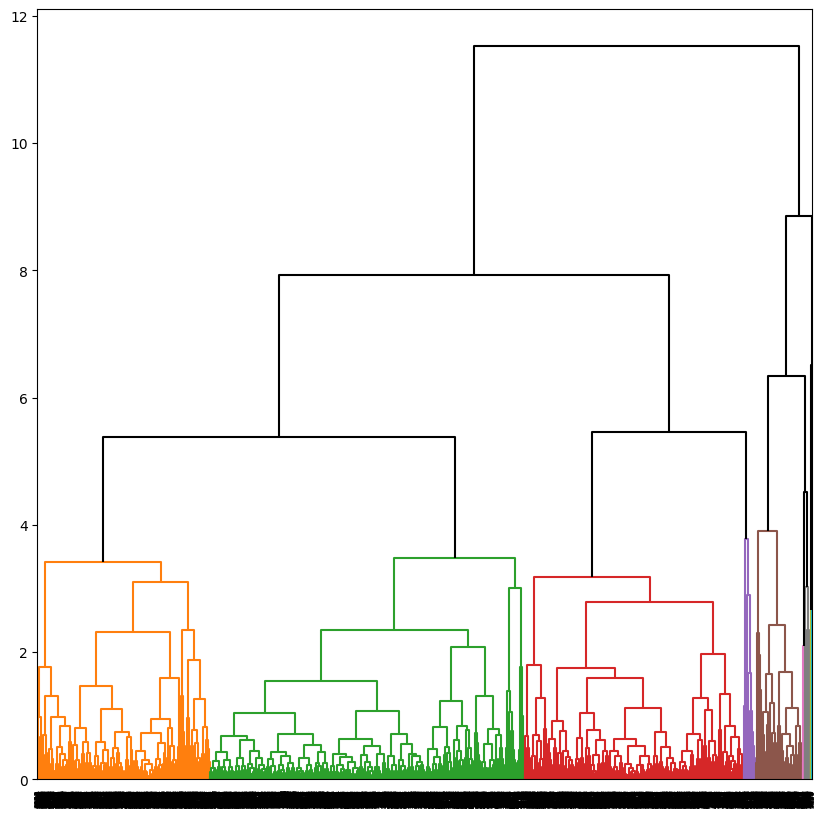

In [35]:
linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(10,10))
dendrogram(linkage_comp,
           ax=ax,
           color_threshold=4,
           above_threshold_color='black');


In [36]:
# Average linkage
hc_avg = HClust(distance_threshold=0,
                n_clusters=None,
                linkage='average');
hc_avg.fit(features)

AgglomerativeClustering(distance_threshold=0, linkage='average',
                        n_clusters=None)

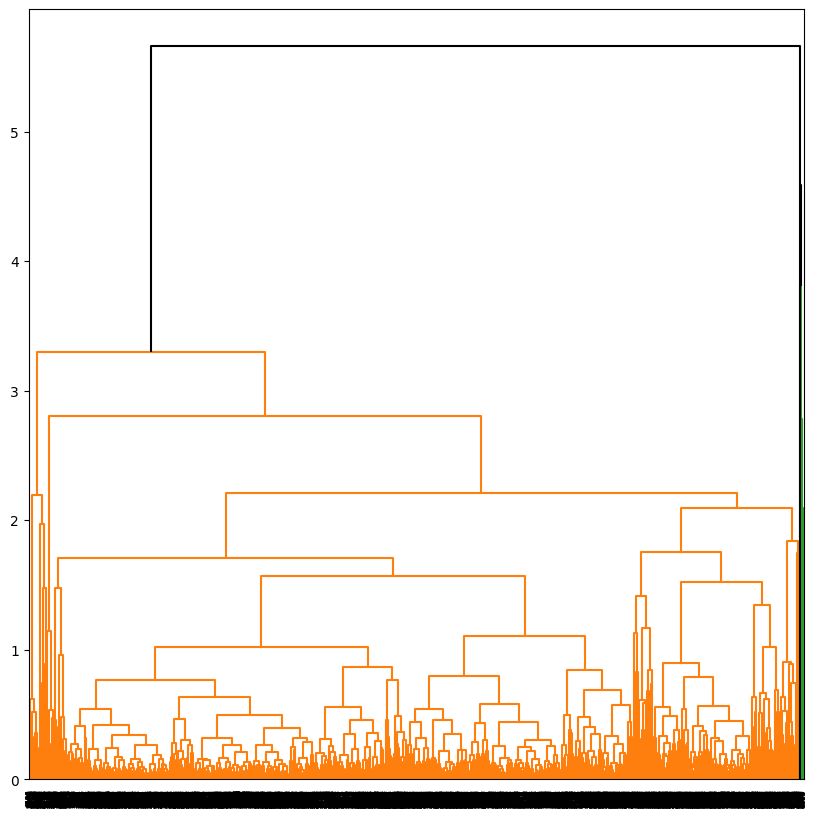

In [37]:
linkage_comp = compute_linkage(hc_avg)
fig, ax = plt.subplots(1, 1, figsize=(10,10))
dendrogram(linkage_comp,
           ax=ax,
           color_threshold=4,
           above_threshold_color='black');

The dendrograms generated from hierarchical clustering show how F1 race observations merge into clusters based on pit stop duration and pit stop timing variables. The complete linkage dendrogram produced more compact and clearly seperated groups, while the average linkage dendrogram showed a chaining effect where observation merged sequentially into elongated clusters. Based on the branching structure and merged distances, approximately 3 clusters appear to provide a meaningful grouping of the race strategies before large cluster merges occur. These clusters may represent different pit stop strategy patterns such as aggressive, balanced and conservative approaches.